# 3. The cost & gate zoos

unitrack ships a catalogue of **cost producers** (functions
from `(tracklets, detections)` to a `CostExpression`) and
**gate producers** (functions to a `Gate` variant). Mixing
and matching them is most of the design space the paper
explores.

This notebook visualizes each one on small toy inputs so
you can see at a glance what shape each module produces.


In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from unitrack.costs import (
    BiSoftmax,
    BoxCIoU,
    BoxGIoU,
    BoxIoU,
    CDist,
    Chamfer,
    Cosine,
    Mahalanobis,
    MaskIoU,
    RBF,
    Reduce,
    Weighted,
)
from unitrack.data import Detections, FrameContext, Gate, Tracklets
from unitrack.gates import (
    ClassGate,
    MotionGate,
    NoneGate,
    ScoreGate,
    SpatialGate2D,
    SpatialGate3D,
)
from unitrack.lifecycle import TrackletStatus

torch.manual_seed(0)
ctx = FrameContext.make(frame_idx=0, delta=0.0)


## A common toy fixture

Throughout this notebook we'll use 3 tracklets vs 4 detections
with synthetic kernel embeddings, masks, bboxes, and centroids.


In [2]:
N, M, D = 3, 4, 8


def make_tracklets(
    *, kernel=None, mask=None, bbox=None, centroid=None, cov=None, klass=None
):
    base = dict(
        id=torch.arange(N, dtype=torch.int64),
        status=torch.full((N,), int(TrackletStatus.Active), dtype=torch.int8),
        hits=torch.ones(N, dtype=torch.int32),
        time_since_update=torch.zeros(N, dtype=torch.int32),
        age=torch.ones(N, dtype=torch.int32),
        frame_started=torch.zeros(N, dtype=torch.int32),
        frame_last_seen=torch.zeros(N, dtype=torch.int32),
        batch_size=[N],
    )
    if kernel is not None:
        base["kernel"] = kernel
    if mask is not None:
        base["mask"] = mask
    if bbox is not None:
        base["bbox"] = bbox
    if centroid is not None:
        base["centroid"] = centroid
    if cov is not None:
        base["centroid_cov"] = cov
    if klass is not None:
        base["klass"] = klass
    return Tracklets(**base)


def make_dets(
    *, kernel=None, mask=None, bbox=None, centroid=None, klass=None, score=None
):
    base = dict(
        index=torch.arange(M, dtype=torch.int64),
        batch_size=[M],
    )
    if kernel is not None:
        base["kernel"] = kernel
    if mask is not None:
        base["mask"] = mask
    if bbox is not None:
        base["bbox"] = bbox
    if centroid is not None:
        base["centroid"] = centroid
    if klass is not None:
        base["klass"] = klass
    if score is not None:
        base["score"] = score
    return Detections(**base)


# Three tracklets with somewhat-distinct kernel embeddings:
cs_kernel = torch.tensor(
    [
        [1, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0],
    ],
    dtype=torch.float32,
)
# Four detections — first 3 close to corresponding tracklets, last is novel.
ds_kernel = torch.tensor(
    [
        [0.9, 0.1, 0, 0, 0, 0, 0, 0],  # close to cs[0]
        [0.1, 0.9, 0, 0, 0, 0, 0, 0],  # close to cs[1]
        [0, 0.1, 0.9, 0, 0, 0, 0, 0],  # close to cs[2]
        [0, 0, 0, 1, 0, 0, 0, 0],  # novel
    ],
    dtype=torch.float32,
)


## Heatmap helper

We'll plot every cost matrix the same way: tracklets on the
rows, detections on the columns, colorbar with low = better
match.


In [3]:
def plot_cost(matrix: torch.Tensor, title: str, ax=None, cmap="viridis"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3))
    disp = matrix.detach().clone()
    if torch.isinf(disp).any():
        disp[torch.isinf(disp)] = disp[~torch.isinf(disp)].max() * 2
    im = ax.imshow(disp.numpy(), cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("ds")
    ax.set_ylabel("cs")
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix[i, j].item()
            label = "∞" if not np.isfinite(v) else f"{v:.2f}"
            ax.text(j, i, label, ha="center", va="center", color="white", fontsize=8)
    return ax


## The appearance fixture, before any cost

Every distance/similarity cost below reads the 8-dim `kernel`
field. Here are the raw embeddings the costs see: three tracklet
rows (`cs`) and four detection rows (`ds`). Rows 0–2 of `ds` are
near-copies of the matching `cs` row; `ds` row 3 lights up a
different dimension — a novel object with no tracklet to match.


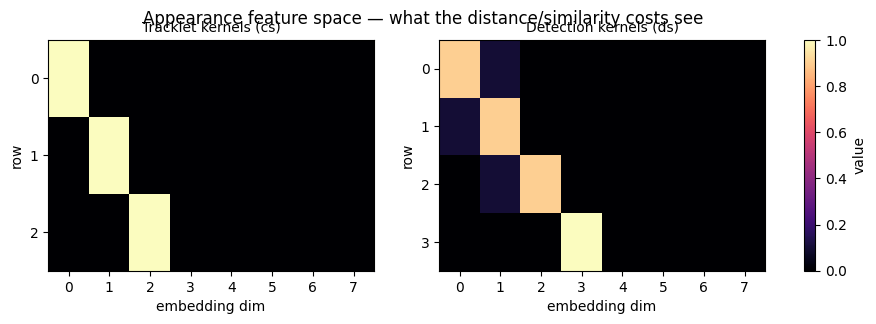

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, emb, title in [
    (axes[0], cs_kernel, "Tracklet kernels (cs)"),
    (axes[1], ds_kernel, "Detection kernels (ds)"),
]:
    im = ax.imshow(emb.numpy(), cmap="magma", vmin=0, vmax=1, aspect="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("embedding dim")
    ax.set_ylabel("row")
    ax.set_yticks(range(emb.shape[0]))
    ax.set_xticks(range(emb.shape[1]))
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, label="value")
fig.suptitle("Appearance feature space — what the distance/similarity costs see")
plt.show()


## Distance / similarity costs over kernel embeddings

- **Cosine** — `1 − cos(a, b)`. Direction-only; magnitude irrelevant.
- **CDist** — `‖a − b‖_p` Minkowski distance (default p=2).
- **BiSoftmax** — bidirectional softmax similarity (paper-aligned).
- **RBF** — `1 − exp(−γ ‖a − b‖²)`; kernel-style similarity.


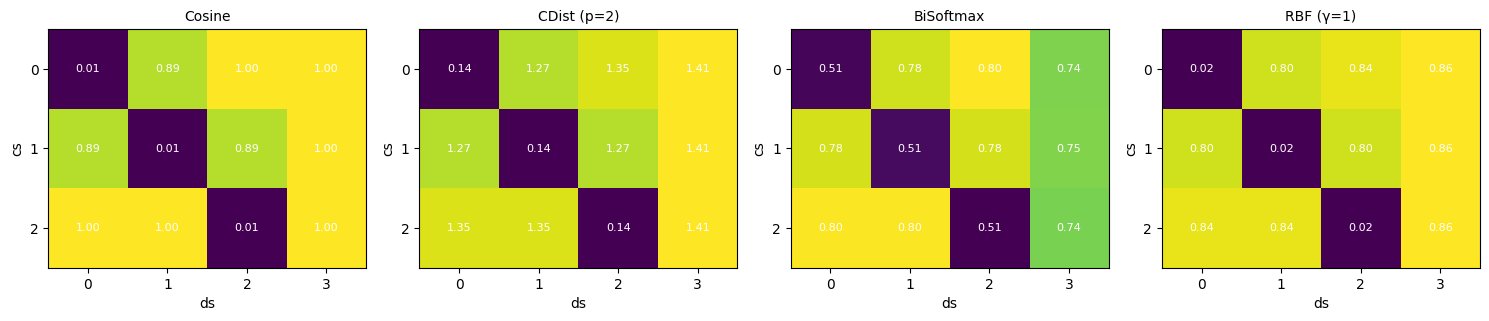

In [5]:
cs = make_tracklets(kernel=cs_kernel)
ds = make_dets(kernel=ds_kernel)

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
plot_cost(Cosine("kernel")(cs, ds, ctx).matrix, "Cosine", ax=axes[0])
plot_cost(CDist("kernel")(cs, ds, ctx).matrix, "CDist (p=2)", ax=axes[1])
plot_cost(BiSoftmax("kernel")(cs, ds, ctx).matrix, "BiSoftmax", ax=axes[2])
plot_cost(RBF("kernel", gamma=1.0)(cs, ds, ctx).matrix, "RBF (γ=1)", ax=axes[3])
plt.tight_layout()
plt.show()


Notice the diagonals of the first three: each tracklet has its
lowest cost at the matching detection (0, 1, 2) and a high
cost at the novel detection (3). RBF compresses the contrast
because exp(0) ≈ 1 for already-close pairs.


## Overlap costs over masks and bboxes

- **MaskIoU** — `1 − IoU` over bitmasks.
- **BoxIoU** — plain `1 − IoU`.
- **BoxGIoU** — `1 − GIoU` (penalizes enclosing area).
- **BoxCIoU** — `1 − CIoU` (penalizes centre offset + aspect ratio).

Below we test on bounding boxes that are mostly aligned but
have one outlier.


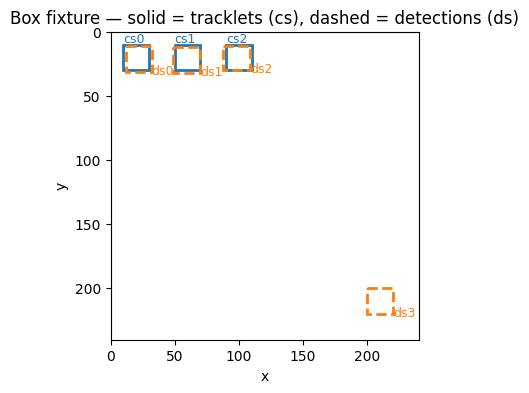

In [6]:
# Three tracklets, four detections; identity bboxes near-overlap.
cs_box = torch.tensor(
    [
        [10, 10, 30, 30],
        [50, 10, 70, 30],
        [90, 10, 110, 30],
    ],
    dtype=torch.float32,
)
ds_box = torch.tensor(
    [
        [12, 11, 32, 31],  # close to cs[0]
        [49, 12, 70, 32],  # close to cs[1]
        [88, 11, 109, 30],  # close to cs[2]
        [200, 200, 220, 220],  # far from all
    ],
    dtype=torch.float32,
)

# Draw the boxes themselves before scoring them.
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(7, 4))
for i, (x0, y0, x1, y1) in enumerate(cs_box.tolist()):
    ax.add_patch(
        mpatches.Rectangle(
            (x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="tab:blue", linewidth=2
        )
    )
    ax.text(x0, y0 - 2, f"cs{i}", color="tab:blue", fontsize=9)
for j, (x0, y0, x1, y1) in enumerate(ds_box.tolist()):
    ax.add_patch(
        mpatches.Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            fill=False,
            edgecolor="tab:orange",
            linewidth=2,
            linestyle="--",
        )
    )
    ax.text(x1, y1 + 2, f"ds{j}", color="tab:orange", fontsize=9)
ax.set_xlim(0, 240)
ax.set_ylim(240, 0)  # image convention: y down
ax.set_aspect("equal")
ax.set_title("Box fixture — solid = tracklets (cs), dashed = detections (ds)")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()


Three detection boxes hug their matching tracklet; `ds3` sits far
away with no overlap. The IoU-family costs below turn that picture
into numbers.


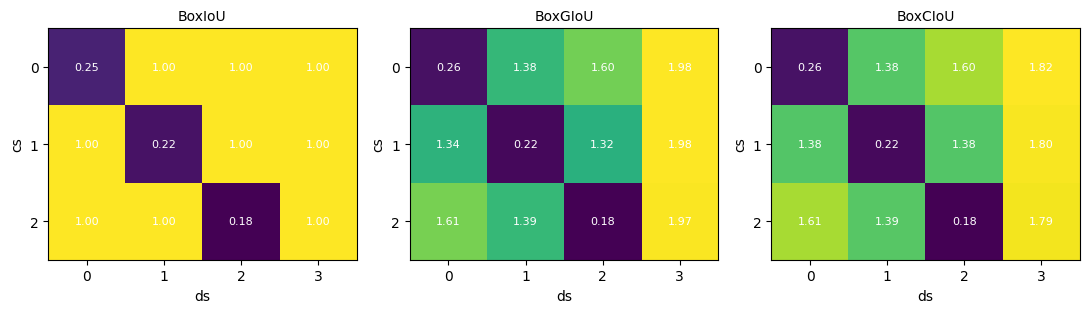

In [7]:
cs_b = make_tracklets(bbox=cs_box)
ds_b = make_dets(bbox=ds_box)

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
plot_cost(BoxIoU("bbox")(cs_b, ds_b, ctx).matrix, "BoxIoU", ax=axes[0])
plot_cost(BoxGIoU("bbox")(cs_b, ds_b, ctx).matrix, "BoxGIoU", ax=axes[1])
plot_cost(BoxCIoU("bbox")(cs_b, ds_b, ctx).matrix, "BoxCIoU", ax=axes[2])
plt.tight_layout()
plt.show()


## Mahalanobis distance — Kalman-style gating

`Mahalanobis(field, cov_field)` reads a per-tracklet covariance
matrix from the snapshot and computes
$(a-b)^T \Sigma^{-1} (a-b)$ over each pair. With identity
covariance this is squared L2; with anisotropic covariance,
elongation along the dominant axis is "free."


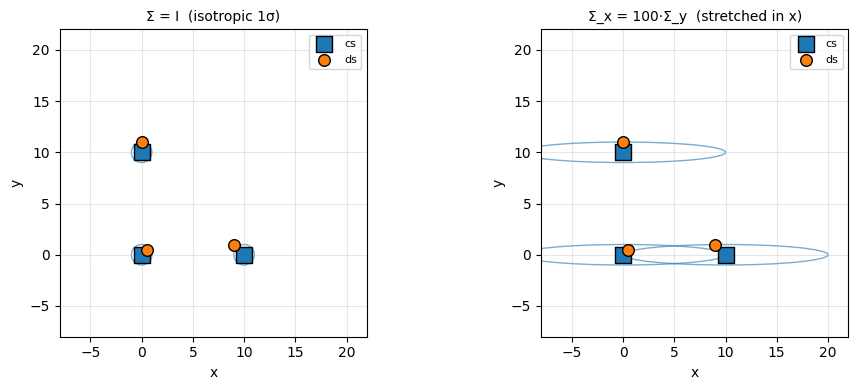

In [8]:
from matplotlib.patches import Ellipse

cs_pos = torch.tensor([[0.0, 0.0], [10.0, 0.0], [0.0, 10.0]])
ds_pos = torch.tensor([[0.5, 0.5], [9.0, 1.0], [0.0, 11.0], [50.0, 50.0]])

eye_cov = torch.eye(2).expand(N, 2, 2).contiguous()
aniso = torch.eye(2).clone()
aniso[0, 0] = 100.0  # 100x the variance along x
aniso_cov = aniso.expand(N, 2, 2).contiguous()


# The geometry: centroids, plus each tracklet's 1-sigma covariance
# ellipse. Mahalanobis distance measures how many sigmas a detection
# sits from a tracklet — so points inside a wide ellipse are "cheap."
def draw_centroids(ax, cov, title):
    ax.scatter(
        cs_pos[:, 0],
        cs_pos[:, 1],
        marker="s",
        s=120,
        color="tab:blue",
        edgecolor="black",
        label="cs",
        zorder=3,
    )
    ax.scatter(
        ds_pos[:, 0],
        ds_pos[:, 1],
        marker="o",
        s=70,
        color="tab:orange",
        edgecolor="black",
        label="ds",
        zorder=3,
    )
    for i in range(N):
        w = 2 * float(cov[i, 0, 0]) ** 0.5  # 1-sigma full width
        h = 2 * float(cov[i, 1, 1]) ** 0.5
        ax.add_patch(
            Ellipse(
                cs_pos[i].tolist(),
                w,
                h,
                angle=0,
                fill=False,
                edgecolor="tab:blue",
                alpha=0.6,
            )
        )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_xlim(-8, 22)
    ax.set_ylim(-8, 22)  # ds3 (50,50) is off-plot
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
draw_centroids(axes[0], eye_cov, "Σ = I  (isotropic 1σ)")
draw_centroids(axes[1], aniso_cov, "Σ_x = 100·Σ_y  (stretched in x)")
plt.tight_layout()
plt.show()


Now the cost matrices for the same two covariance settings (the
far-away `ds3` is the easy reject in both):


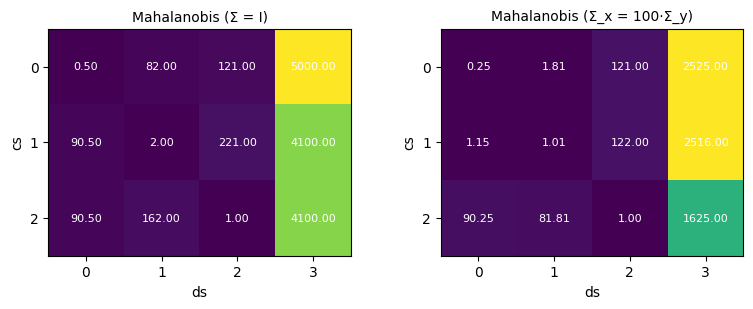

In [9]:
ds = make_dets(centroid=ds_pos)

cs = make_tracklets(centroid=cs_pos, cov=eye_cov)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_cost(
    Mahalanobis("centroid", "centroid_cov")(cs, ds, ctx).matrix,
    "Mahalanobis (Σ = I)",
    ax=axes[0],
)

cs = make_tracklets(centroid=cs_pos, cov=aniso_cov)
plot_cost(
    Mahalanobis("centroid", "centroid_cov")(cs, ds, ctx).matrix,
    "Mahalanobis (Σ_x = 100·Σ_y)",
    ax=axes[1],
)
plt.tight_layout()
plt.show()


Notice how the high-variance-x covariance flattens the cost
differences along the x axis — a tracklet that's been tracked
with much position uncertainty in x cares less about a
detection that's a few units off in x.


## Combinators — mixing costs

- **Reduce** combines K cost matrices with a reduction
  (`sum`, `mean`, `min`, `max`, `product`).
- **Weighted** scales an inner cost by a constant.
- **Sinkhorn** (not visualized here) renormalises a cost via
  entropy-regularized OT — relevant for differentiable tracking.


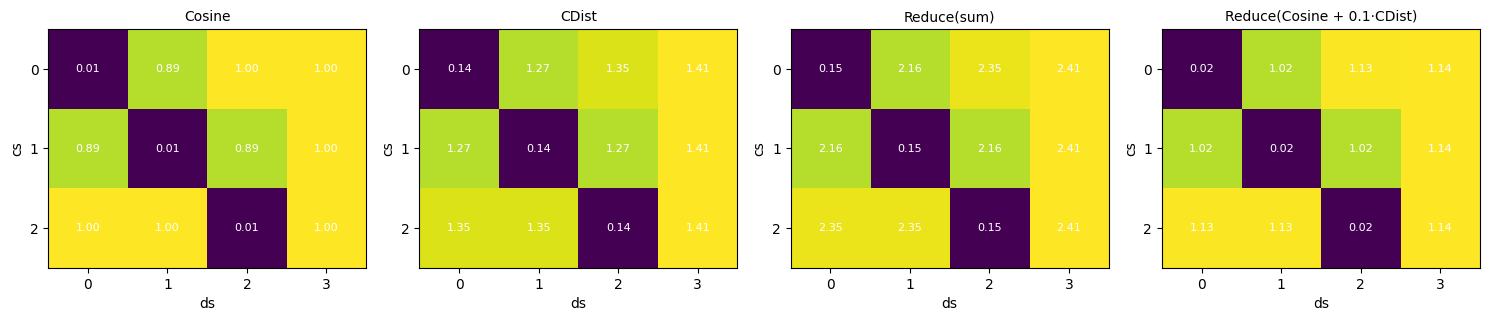

In [10]:
cs = make_tracklets(kernel=cs_kernel)
ds = make_dets(kernel=ds_kernel)
cosine = Cosine("kernel")
cdist = CDist("kernel")

sum_cost = Reduce([cosine, cdist], "sum")(cs, ds, ctx).matrix
weighted = Reduce([cosine, Weighted(cdist, weight=0.1)], "sum")(cs, ds, ctx).matrix

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
plot_cost(cosine(cs, ds, ctx).matrix, "Cosine", ax=axes[0])
plot_cost(cdist(cs, ds, ctx).matrix, "CDist", ax=axes[1])
plot_cost(sum_cost, "Reduce(sum)", ax=axes[2])
plot_cost(weighted, "Reduce(Cosine + 0.1·CDist)", ax=axes[3])
plt.tight_layout()
plt.show()


## Gates — boolean (or biased) acceptance over pairs

Gates filter or penalise (cs, ds) pairs *before* the
associator runs. The unitrack catalogue:

- **NoneGate** — identity. Every pair survives.
- **ClassGate(field)** — pairs allowed iff their class fields agree.
- **ScoreGate(field, threshold)** — drops detections whose score is below threshold (per-side).
- **SpatialGate2D / 3D** — drops pairs whose Euclidean distance exceeds a threshold.
- **MotionGate** — Mahalanobis χ² gate (Kalman-aware).


In [11]:
# Build a richer fixture so each gate has something to act on.
# Centroids carry a z-axis so the 3-D spatial gate has a third
# component to act on; the 2-D gate ignores the trailing coordinate.
cs_kernel_g = cs_kernel
ds_kernel_g = ds_kernel
cs_klass = torch.tensor([0, 1, 0])
ds_klass = torch.tensor([0, 1, 0, 2])
ds_score = torch.tensor([0.9, 0.6, 0.4, 0.95])
cs_pos_g = torch.tensor([[0.0, 0.0, 0.0], [50.0, 0.0, 0.0], [100.0, 0.0, 0.0]])
ds_pos_g = torch.tensor(
    [[2.0, 0.0, 0.0], [49.0, 1.0, 0.0], [98.0, 0.0, 0.0], [200.0, 0.0, 0.0]]
)

cs = make_tracklets(kernel=cs_kernel_g, centroid=cs_pos_g, klass=cs_klass)
ds = make_dets(kernel=ds_kernel_g, centroid=ds_pos_g, klass=ds_klass, score=ds_score)


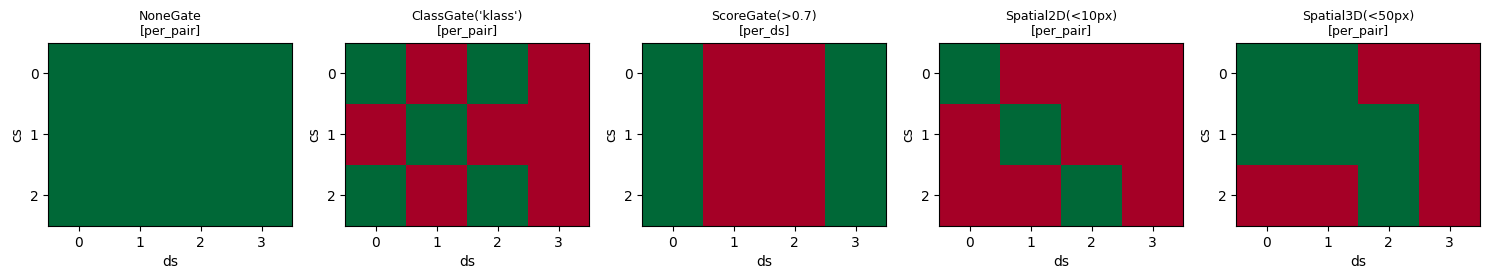

In [12]:
def show_gate(g_call, title, ax):
    g = g_call(cs, ds, ctx)
    if g.kind == "per_pair":
        m = g.mask
    elif g.kind == "per_cs":
        m = g.mask[:, None].expand(-1, M)
    elif g.kind == "per_ds":
        m = g.mask[None, :].expand(N, -1)
    else:
        m = torch.ones((N, M), dtype=torch.bool)
    ax.imshow(m.numpy().astype(float), cmap="RdYlGn", vmin=0, vmax=1)
    ax.set_title(f"{title}\n[{g.kind}]", fontsize=9)
    ax.set_xlabel("ds")
    ax.set_ylabel("cs")
    ax.set_xticks(range(M))
    ax.set_yticks(range(N))


fig, axes = plt.subplots(1, 5, figsize=(15, 3))
show_gate(NoneGate(), "NoneGate", axes[0])
show_gate(ClassGate("klass"), "ClassGate('klass')", axes[1])
show_gate(ScoreGate("score", threshold=0.7), "ScoreGate(>0.7)", axes[2])
show_gate(SpatialGate2D("centroid", max_dist=10.0), "Spatial2D(<10px)", axes[3])
show_gate(SpatialGate3D("centroid", max_dist=50.0), "Spatial3D(<50px)", axes[4])
plt.tight_layout()
plt.show()


Reading the heatmaps: green = pair allowed; red = pair rejected.

## Gate composition

Gates form a closed algebra under conjunction. Cross-kind
pairs are promoted to the smallest variant that holds the
result:

| a            | b            | result |
|--------------|--------------|--------|
| PerCs        | PerCs        | PerCs |
| PerDs        | PerDs        | PerDs |
| PerCs        | PerDs        | PerPair (outer-AND) |
| any          | PerPair      | PerPair |
| CostBias     | CostBias     | CostBias (sum) |

Combining `ClassGate` (per-pair) with `ScoreGate` (per-ds)
promotes to per-pair:


ClassGate kind:  per_pair
ScoreGate kind:  per_ds
Combined kind:   per_pair


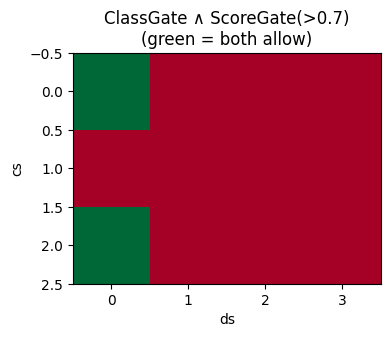

In [13]:
gA = ClassGate("klass")(cs, ds, ctx)  # per_pair
gB = ScoreGate("score", threshold=0.7)(cs, ds, ctx)  # per_ds
combined = Gate.combine(gA, gB)
print(f"ClassGate kind:  {gA.kind}")
print(f"ScoreGate kind:  {gB.kind}")
print(f"Combined kind:   {combined.kind}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(combined.mask.numpy().astype(float), cmap="RdYlGn", vmin=0, vmax=1)
ax.set_title("ClassGate ∧ ScoreGate(>0.7)\n(green = both allow)")
ax.set_xlabel("ds")
ax.set_ylabel("cs")
plt.show()


## What's next

Notebook **4** wires costs and gates into composable pipelines
with `Pipe`, `Sequential`, `Parallel`, `Gated`, `Filter`, and
`Iterate` — these are the combinators that build up actual
trackers.
